# From 1,000 Companies to an Investment Shortlist

## A Matplotlib-based business reporting notebook

You are a financial analyst. Your task is to transform a raw universe of listed companies into a short, defensible investment watchlist.

This notebook is designed for a data analytics class. It does not try to produce professional investment advice. Instead, it shows how charts help analysts answer business questions, communicate evidence, and progressively improve a visualization.

The central question is:

> **Which companies deserve further investment analysis, and why?**

We will use several chart types:

- Histogram
- Bar chart
- Boxplot
- Scatter plot
- Bubble chart
# From 1,000 Companies to an Investment Shortlist

## A Matplotlib-based business reporting notebook

You are a financial analyst. Your task is to transform a raw universe of listed companies into a short, defensible investment watchlist.

This notebook is designed for a data analytics class. It does not try to produce professional investment advice. Instead, it shows how charts help analysts answer business questions, communicate evidence, and progressively improve a visualization.

The central question is:

> **Which companies deserve further investment analysis, and why?**

We will use several chart types:

- Histogram
- Bar chart
- Boxplot
- Scatter plot
- Bubble chart
- Treemap chart
- Line chart
- Final score chart

For each major section, we follow the same reporting logic:

1. Define a business question.
2. Build a first simple chart.
3. Improve the chart with labels, colors, annotations, sorting, reference lines, or better scaling.
4. Extract a business interpretation.
- Line chart
- Final score chart

For each major section, we follow the same reporting logic:

1. Define a business question.
2. Build a first simple chart.
3. Improve the chart with labels, colors, annotations, sorting, reference lines, or better scaling.
4. Extract a business interpretation.

In [2]:
# ============================================================
# 1. Import libraries
# ============================================================

# pandas is used for data loading, cleaning, filtering and aggregation.
import pandas as pd

# numpy is useful for numerical operations and handling missing/infinite values.
import numpy as np

# matplotlib is the core visualization library used in this notebook.
import matplotlib.pyplot as plt

# matplotlib.ticker helps us format axis labels in a readable way.
from matplotlib.ticker import FuncFormatter

# Optional: make pandas display more columns when we inspect the dataset.
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# A small global setting: larger default figure size improves readability in class.
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = False

In [3]:
# ============================================================
# 2. Load the dataset
# ============================================================

# Load the dataset from the CSV file named "data/symbol_info_3-25.csv" into a pandas DataFrame.
df_raw = pd.read_csv("data/symbol_info_3-25.csv")

# Show the dataset shape: rows and columns.
print("Dataset shape:", df_raw.shape)

# Preview the first rows.
df_raw.head()

Dataset shape: (1000, 38)


,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,fifty_day_average,two_hundred_day_avg,beta,pe_trailing,pe_forward,price_to_sales,price_to_book,total_revenue,net_income,profit_margins,free_cashflow,debt_to_equity,return_on_assets,return_on_equity,revenue_growth,earnings_growth,last_annual_dividend,dividend_yield,payout_ratio,average_volume,short_ratio,exchange,exchange_short_name,country,is_etf,is_fund,is_actively_trading,timestamp
0,AAPL,Apple Inc.,Technology,Consumer Electronics,3278873821184,3321891913728,218.270004,214.100006,260.100006,164.080002,231.919006,228.354950,1.178,34.591125,26.265944,8.285006,49.182064,395760009216,96150003712,0.24295,93833871360,145.000000,0.22519,1.36520,0.040,0.101,1.00,0.46,0.1571,52181373,2.71,NMS,NMS,United States,0,0,1,2025-03-22 04:50:05
1,MSFT,Microsoft Corporation,Technology,Software - Infrastructure,2908619014144,2939973795840,391.260010,386.839996,468.350006,376.910004,408.945801,423.364349,0.914,31.553228,26.171238,11.109996,9.610435,261802000384,92749996032,0.35428,51958124544,33.998001,0.14649,0.34291,0.123,0.102,3.32,0.85,0.2482,22370941,2.68,NMS,NMS,United States,0,0,1,2025-03-22 04:50:07
2,NVDA,NVIDIA Corporation,Technology,Semiconductors,2892136185856,2838940090368,117.699997,118.529999,153.130005,75.606003,126.937798,127.763115,1.765,40.034012,28.567961,22.162472,36.315952,130497003520,72879996928,0.55848,44169748480,12.946000,0.57417,1.19177,0.779,0.836,0.04,0.03,0.0116,271988186,0.84,NMS,NMS,United States,0,0,1,2025-03-22 04:50:06
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,Internet Retail,2079374704640,2133579530240,196.210007,194.949997,242.520004,151.610001,218.631393,199.768295,1.192,35.481014,31.904066,3.259417,7.268114,637959012352,59248001024,0.09287,44635873280,54.341999,0.07438,0.24290,0.105,0.846,0.00,0.00,0.0000,38226331,1.78,NMS,NMS,United States,0,0,1,2025-03-22 04:50:08
4,GOOGL,Alphabet Inc.,Communication Services,Internet Content & Information,1996906430464,1931518148608,163.990005,162.800003,207.050003,147.220001,182.666000,175.225204,1.025,20.396767,18.302456,5.705153,6.159943,350018011136,100118003712,0.28604,56580751360,8.655000,0.16740,0.32908,0.118,0.309,0.80,0.49,0.0746,29147868,2.01,NMS,NMS,United States,0,0,1,2025-03-22 04:50:09


In [4]:
# ============================================================
# 3. Inspect columns and missing values
# ============================================================

# A real analyst should never start plotting before understanding the data.
# Here we inspect column names, data types and missing values.

summary = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": df_raw.dtypes.astype(str).values,
    "missing_values": df_raw.isna().sum().values,
    "missing_pct": (df_raw.isna().mean().values * 100).round(2)
})

summary

,column,dtype,missing_values,missing_pct
0,symbol,object,0,0.0
1,company_name,object,0,0.0
2,sector,object,2,0.2
3,industry,object,2,0.2
4,market_cap,int64,0,0.0
5,enterprise_value,uint64,0,0.0
6,current_price,float64,0,0.0
7,previous_close,float64,0,0.0
8,fifty_two_week_high,float64,0,0.0
9,fifty_two_week_low,float64,0,0.0


## Data preparation

The raw dataset contains companies, ETFs, funds, active and inactive securities, and several financial indicators.

For this lesson, we restrict the analysis to active operating companies. This is not the only possible choice, but it makes the business story cleaner.

We also create readable columns expressed in billions of dollars or percentages. This improves chart readability and avoids large unreadable axis values.

In [5]:
# ============================================================
# 4. Clean the investment universe
# ============================================================

# Start from the raw dataset (independent copy)
df = df_raw.copy()

# Keep active operating companies only.
# is_etf == 0 removes ETFs.
# is_fund == 0 removes funds.
# is_actively_trading == 1 keeps securities that are currently trading.
# Positive market cap and revenue avoid invalid or non-meaningful ratios.
df = df[
    (df["is_etf"] == 0) &
    (df["is_fund"] == 0) &
    (df["is_actively_trading"] == 1) &
    (df["market_cap"] > 0) &
    (df["total_revenue"] > 0)
].copy()

# Convert large dollar values into billions.
# This makes charts much easier to read.
df["market_cap_b"] = df["market_cap"] / 1e9
df["enterprise_value_b"] = df["enterprise_value"] / 1e9
df["revenue_b"] = df["total_revenue"] / 1e9
df["net_income_b"] = df["net_income"] / 1e9
df["free_cashflow_b"] = df["free_cashflow"] / 1e9

# Convert decimal ratios into percentages where appropriate.
# Example: 0.24 becomes 24%.
df["profit_margin_pct"] = df["profit_margins"] * 100
df["revenue_growth_pct"] = df["revenue_growth"] * 100
df["earnings_growth_pct"] = df["earnings_growth"] * 100
df["return_on_assets_pct"] = df["return_on_assets"] * 100
df["return_on_equity_pct"] = df["return_on_equity"] * 100

# The dividend_yield column in this dataset is already expressed like 0.46, 0.85, etc.
# We keep a separate column with a clear name.
df["dividend_yield_pct"] = df["dividend_yield"]

# Replace infinite values with missing values.
# Infinite values may appear after divisions or dirty data imports.
df = df.replace([np.inf, -np.inf], np.nan)

print("Cleaned investment universe:", df.shape)
df[["symbol", "company_name", "sector", "market_cap_b", "revenue_b", "profit_margin_pct", "beta"]].head()

Cleaned investment universe: (993, 49)


,symbol,company_name,sector,market_cap_b,revenue_b,profit_margin_pct,beta
0,AAPL,Apple Inc.,Technology,3278.873821,395.760009,24.295001,1.178
1,MSFT,Microsoft Corporation,Technology,2908.619014,261.802000,35.428002,0.914
2,NVDA,NVIDIA Corporation,Technology,2892.136186,130.497004,55.848002,1.765
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,2079.374705,637.959012,9.287000,1.192
4,GOOGL,Alphabet Inc.,Communication Services,1996.906430,350.018011,28.604001,1.025


In [6]:
# ============================================================
# 5. Helper functions for cleaner charts
# ============================================================

# Reusable formatter: show numbers as billions with one decimal.
def billions_formatter(x, pos):
    return f"{x:,.0f}B"

# Reusable formatter: show percentages with no decimal places.
def pct_formatter(x, pos):
    return f"{x:.0f}%"

# Reusable helper to remove unnecessary chart borders.
# This gives a cleaner report-style chart.
def clean_spines(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

# Reusable helper to annotate bars in a horizontal bar chart.
def annotate_hbar(ax, fmt="{:.1f}"):
    for patch in ax.patches:
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(width, y, "  " + fmt.format(width), va="center", fontsize=12)

# Business Question 1

## How concentrated is the market?

Before selecting companies, we need to understand the shape of the investment universe.

A common financial dataset is highly skewed: a small number of mega-cap companies dominate the total market capitalization, while most companies are much smaller.

The histogram helps answer:

> **Are most companies similar in size, or do a few giants dominate the universe?**

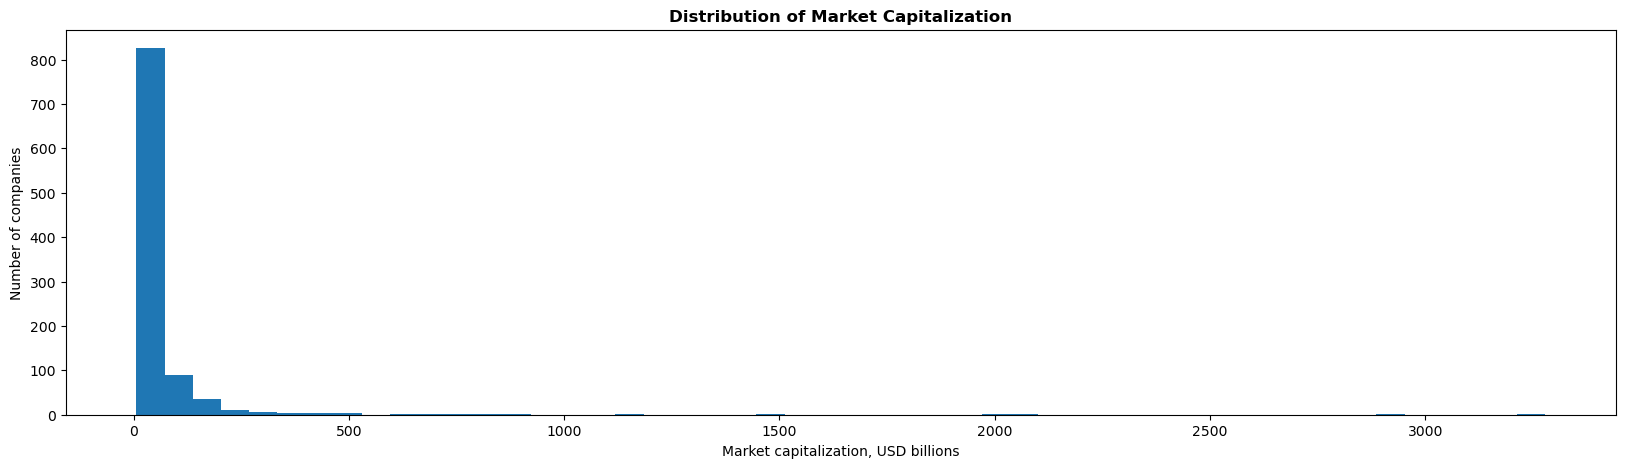

In [7]:
# ============================================================
# 6. Histogram, first version
# ============================================================

# A histogram shows the distribution of one numerical variable.
# Here we start with a basic histogram of market capitalization.

plt.figure(figsize=(20, 5))
plt.hist(df["market_cap_b"].dropna(), bins=50)
plt.title("Distribution of Market Capitalization")
plt.xlabel("Market capitalization, USD billions")
plt.ylabel("Number of companies")
plt.show()

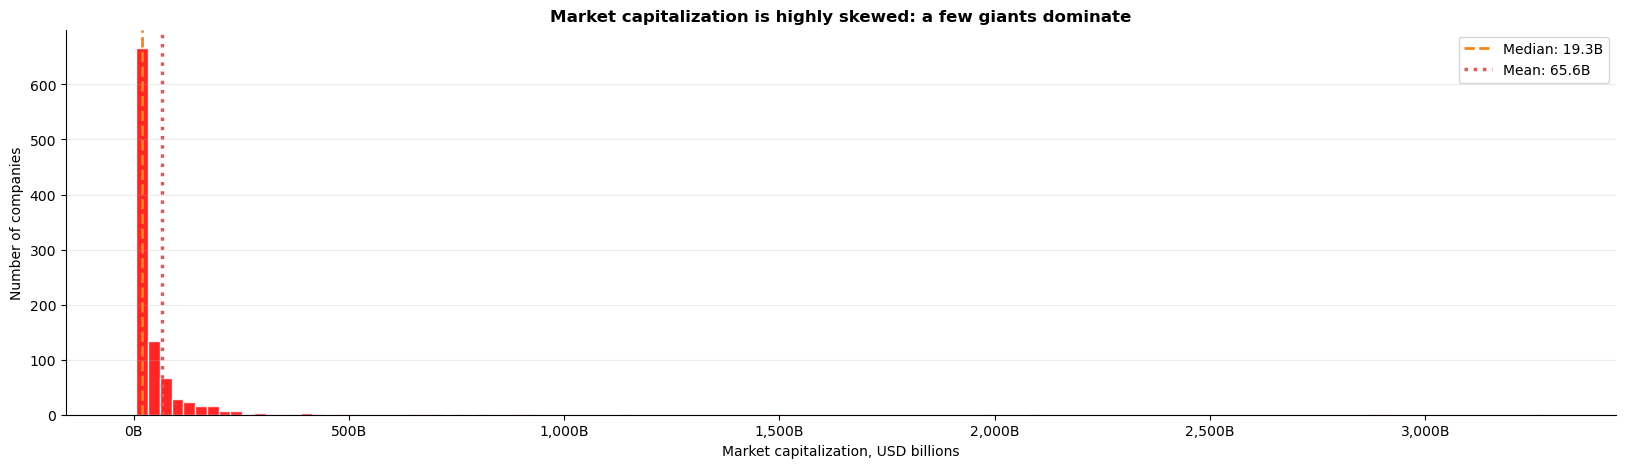

In [8]:
# ============================================================
# 7. Histogram, improved version
# ============================================================

# The first chart works, but it hides the main message.
# Market cap is usually extremely skewed, so we add:
# - a median line
# - a mean line
# - clearer colors
# - grid lines on the y-axis
# - a more interpretive title

market_cap = df["market_cap_b"].dropna()

fig, ax = plt.subplots(figsize=(20, 5))

ax.hist(
    market_cap,          # Data to plot: one numerical value per company.
                         # In this case, market_cap contains the market capitalization values.

    bins=120,             # Number of intervals used to split the data.
                         # More bins = more detail, but the chart may become noisy.
                         # Fewer bins = smoother chart, but less detail.

    color="red",     # Fill color of the bars.
                         # Hexadecimal color code.
                         # This blue is visually clean and works well in business charts.

    edgecolor="white",   # Color of the border around each bar.
                         # White edges help separate adjacent bars visually.

    alpha=0.85           # Transparency level of the bars.
                         # 1.0 means fully opaque.
                         # 0.0 means fully transparent.
                         # 0.85 keeps the color strong but slightly softer.
)

median_value = market_cap.median()
mean_value = market_cap.mean()

ax.axvline(median_value, color="#F58518", linestyle="--", linewidth=2, label=f"Median: {median_value:,.1f}B")
ax.axvline(mean_value, color="#E45756", linestyle=":", linewidth=2.5, label=f"Mean: {mean_value:,.1f}B")

ax.set_title("Market capitalization is highly skewed: a few giants dominate")
ax.set_xlabel("Market capitalization, USD billions")
ax.set_ylabel("Number of companies")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.grid(axis="y", alpha=0.25)
ax.legend()
clean_spines(ax)

plt.show()

### Interpretation

If the mean is much larger than the median, the distribution is right-skewed. That means a few very large companies pull the average upward.

This matters because an investment universe can look diversified by number of companies, but still be economically dominated by a small group of mega-cap names.

# Business Question 2

## Which companies dominate the universe?

A histogram shows the distribution, but it does not identify the actual companies. For that, a sorted bar chart is more effective.

The bar chart answers:

> **Which companies have the largest market capitalization?**

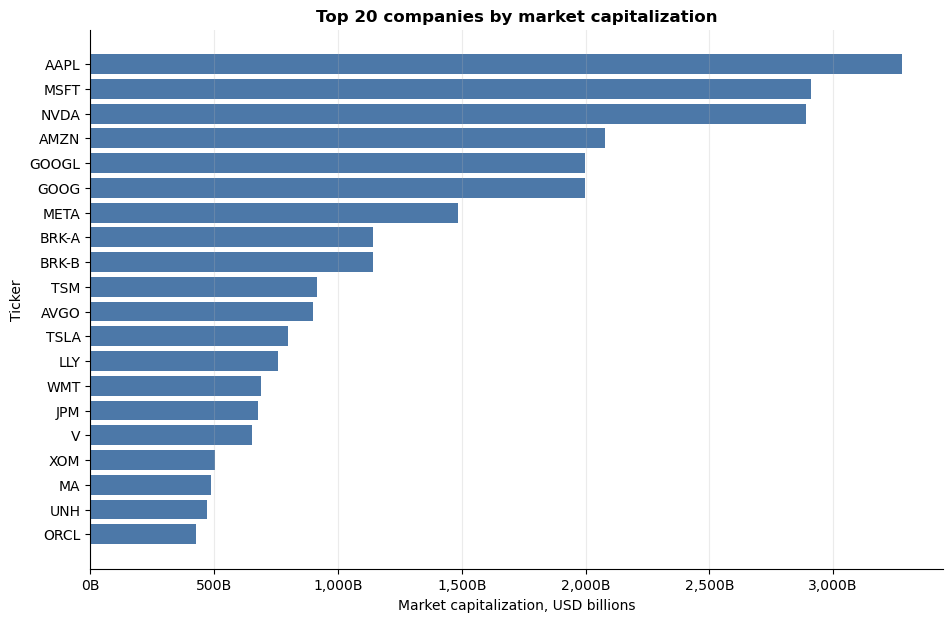

In [9]:
# ============================================================
# 8. Bar chart: top companies by market cap
# ============================================================

# Select the 20 largest companies by market capitalization.
top_market_cap = df.nlargest(20, "market_cap_b").copy()

# Sort ascending for a horizontal bar chart.
# This places the largest value at the top after inverting the y-axis.
top_market_cap = top_market_cap.sort_values("market_cap_b", ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(
    top_market_cap["symbol"],
    top_market_cap["market_cap_b"],
    color="#4C78A8"
)

ax.set_title("Top 20 companies by market capitalization")
ax.set_xlabel("Market capitalization, USD billions")
ax.set_ylabel("Ticker")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.grid(axis="x", alpha=0.25)
clean_spines(ax)

plt.show()

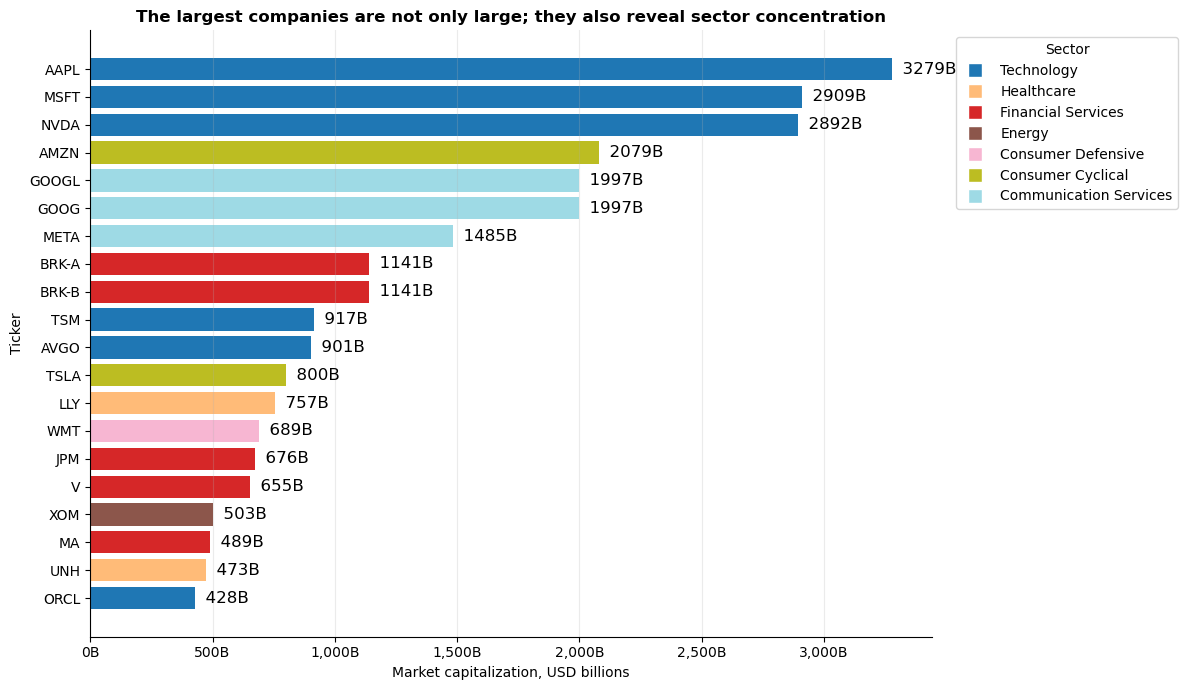

In [10]:
# ============================================================
# 9. Bar chart with sector colors and labels
# ============================================================

# A second version adds categorical color.
# Here, color represents sector.
# This helps students see whether the largest companies are concentrated in one area.

top_market_cap = df.nlargest(20, "market_cap_b").copy()
top_market_cap = top_market_cap.sort_values("market_cap_b", ascending=True)

# Create a color map for sectors.
# Each sector receives a color from the tab20 palette.
sectors = top_market_cap["sector"].fillna("Unknown").unique()
palette = plt.cm.tab20(np.linspace(0, 1, len(sectors)))
sector_to_color = dict(zip(sectors, palette))
colors = top_market_cap["sector"].fillna("Unknown").map(sector_to_color)

fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(top_market_cap["symbol"], top_market_cap["market_cap_b"], color=colors)

ax.set_title("The largest companies are not only large; they also reveal sector concentration")
ax.set_xlabel("Market capitalization, USD billions")
ax.set_ylabel("Ticker")
# Format the X-axis tick labels using a custom function.
# In this case, billions_formatter converts large numbers
# into a more readable financial format, such as $500B or $1.2T.
# This changes only how the axis labels are displayed;
# it does not modify the underlying data.
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.grid(axis="x", alpha=0.25)
clean_spines(ax)

# Add data labels to the bars.
annotate_hbar(ax, fmt="{:.0f}B")

# Create a custom legend.
legend_handles = [
    plt.Line2D([0], [0], marker="s", color="w", label=sector, markerfacecolor=color, markersize=10)
    for sector, color in sector_to_color.items()
]
ax.legend(handles=legend_handles, title="Sector", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

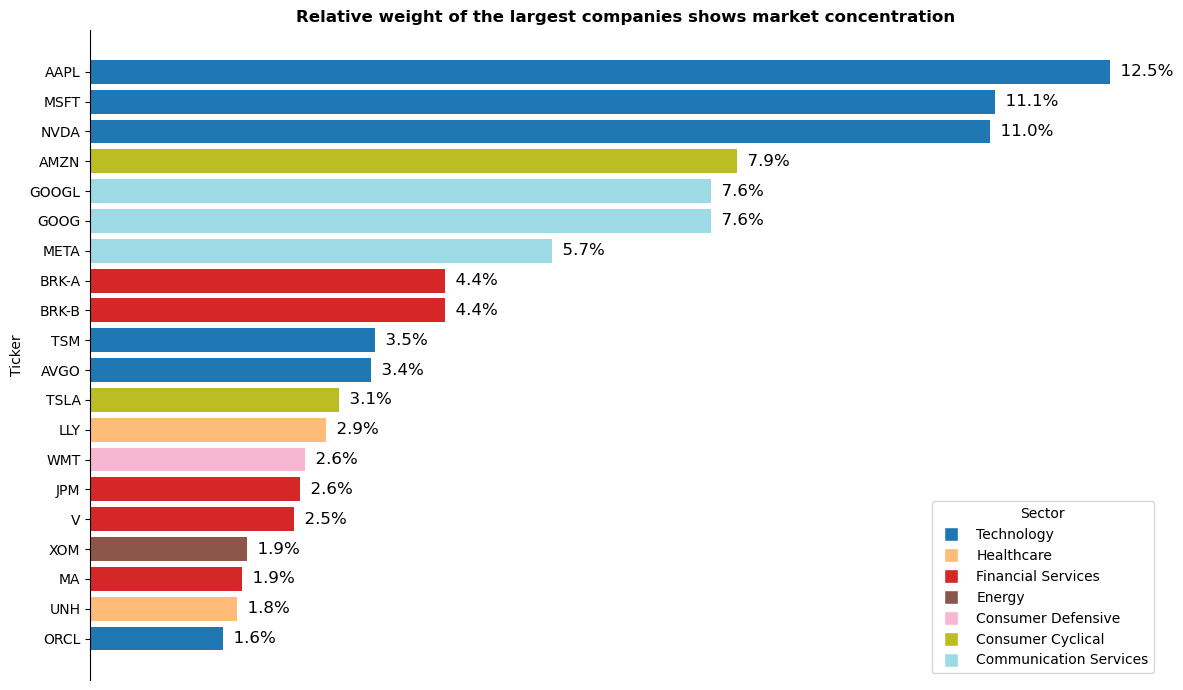

In [11]:
# ============================================================
# 9. Bar chart with sector colors and percentage labels
# ============================================================
# Select the 20 companies with the largest market capitalization.
top_market_cap = df.nlargest(20, "market_cap_b").copy()

# Calculate each company's weight as a percentage of the total market cap
# of the selected Top 20 companies.
#
# Example:
# If Apple has 3,000B market cap and the Top 20 total is 20,000B,
# Apple's percentage will be:
# 3,000 / 20,000 * 100 = 15%

top_market_cap["market_cap_pct"] = (
    top_market_cap["market_cap_b"] / top_market_cap["market_cap_b"].sum() * 100
)

# Sort ascending so the largest bar appears at the top in a horizontal bar chart.
top_market_cap = top_market_cap.sort_values("market_cap_pct", ascending=True)

# Create a color map for sectors.
# Each sector receives a color from the tab20 palette.
sectors = top_market_cap["sector"].fillna("Unknown").unique()
palette = plt.cm.tab20(np.linspace(0, 1, len(sectors)))
sector_to_color = dict(zip(sectors, palette))
colors = top_market_cap["sector"].fillna("Unknown").map(sector_to_color)
fig, ax = plt.subplots(figsize=(12, 7))

# Use the percentage column instead of the market cap in billions.
ax.barh(
    top_market_cap["symbol"],
    top_market_cap["market_cap_pct"],
    color=colors
)

ax.set_title("Relative weight of the largest companies shows market concentration")

# Remove the X-axis label because values are shown directly on the bars.
ax.set_xlabel("")
ax.set_ylabel("Ticker")

# Remove the vertical grid lines.
# The original version used:
# ax.grid(axis="x", alpha=0.25)
# We remove it because the percentage labels on the bars are enough.
ax.grid(False)

# Remove X-axis ticks and tick labels.
# This makes the chart cleaner and more report-like.
ax.tick_params(
    axis="x",
    which="both",
    bottom=False,
    top=False,
    labelbottom=False
)

# Optional: remove the X-axis spine as well.
# This removes the horizontal axis line at the bottom.
ax.spines["bottom"].set_visible(False)

# Keep  custom function to clean the other spines.
clean_spines(ax)

# Add percentage labels to the bars.
# This replaces the previous format "{:.0f}B".
annotate_hbar(ax, fmt="{:.1f}%")

# Create a custom legend.
# We build the legend manually because the bar colors were assigned
# from the sector_to_color dictionary, not automatically by Matplotlib.

legend_handles = [
    plt.Line2D(
        [0], [0],                # Dummy line coordinates.
                                # We do not want to draw an actual line;
                                # we only need an object for the legend.
        marker="s",              # Use a square marker to represent each sector color.
        color="w",               # Make the line itself white/invisible.
        label=sector,            # Text displayed in the legend for this sector.
        markerfacecolor=color,   # Fill the square marker with the sector color.
        markersize=10            # Size of the square marker in the legend.
    )
    for sector, color in sector_to_color.items()
]

# Place the legend inside the chart, in the lower-right corner.
# loc="lower right" anchors the legend box to the lower-right area of the axes.
#

# This is different from the previous version:
# bbox_to_anchor=(1.02, 1), loc="upper left"
# which placed the legend outside the plot area, to the right of the chart.
ax.legend(
    handles=legend_handles,
    title="Sector",
    loc="lower right"
)

plt.tight_layout()

plt.show()

# Business Question 3

## Which sectors dominate by number of companies and by market value?

A sector may contain many companies but represent a small share of total market capitalization. Another sector may contain fewer companies but dominate the market economically.

We therefore compare two views:

1. Number of companies by sector.
2. Total market capitalization by sector.

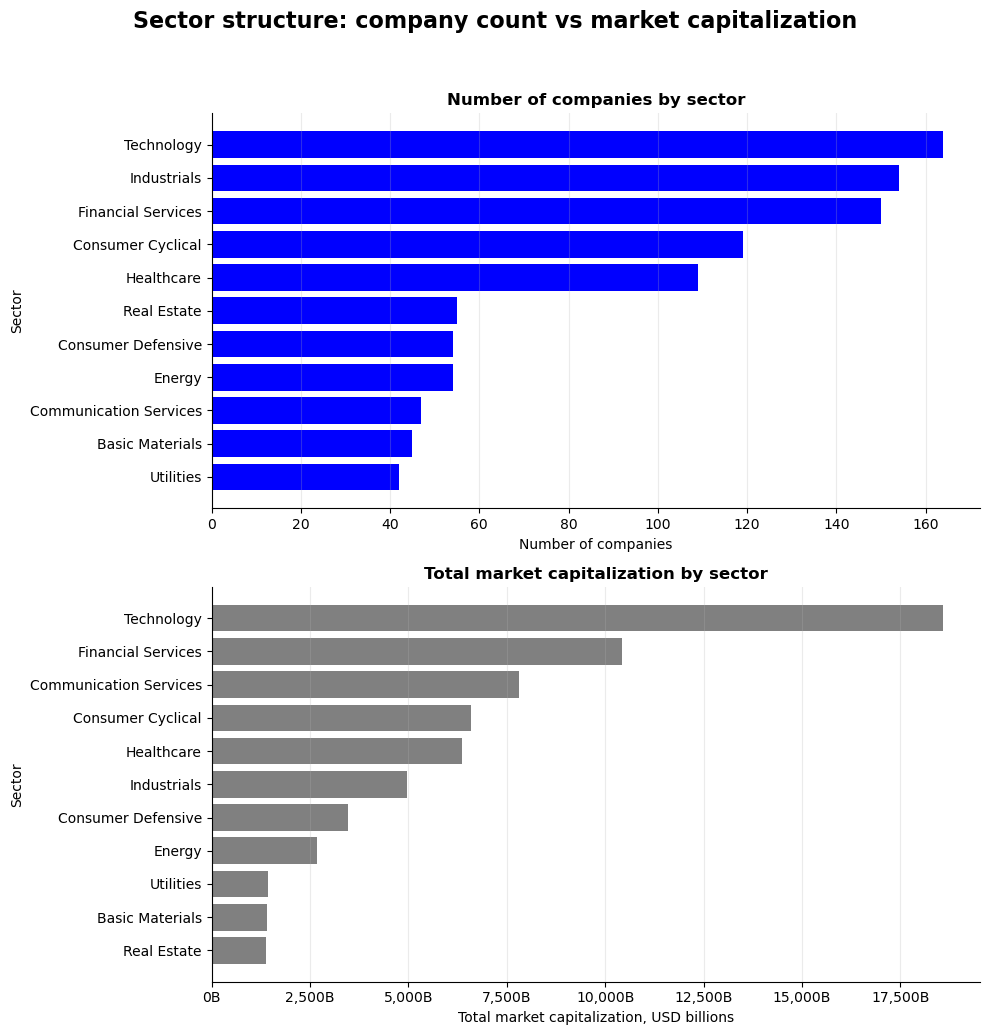

In [12]:
# ============================================================
# 10. Sector overview: count vs economic weight
# ============================================================

# This chart combines two complementary views:
#
# 1. How many companies are in each sector?
# 2. How much total market capitalization does each sector represent?
#

# Missing sector values are replaced with "Unknown".
sector_count = (
    df["sector"]
    .fillna("Unknown")
    .value_counts()
    .sort_values(ascending=True)
)

# Calculate the total market capitalization for each sector.
# Again, missing sector values are replaced with "Unknown".

sector_cap = (
    df
    .assign(sector_clean=df["sector"].fillna("Unknown"))
    .groupby("sector_clean")["market_cap_b"]
    .sum()
    .sort_values(ascending=True)
)

# Create one figure with two charts side by side:
# 1 row, 2 columns.
#
# sharey=False means each subplot keeps its own Y-axis labels.
# This is useful because the two rankings may have different orders.

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10, 10),
    sharey=False
)

# Give meaningful names to the two axes.
ax_count = axes[0]
ax_cap = axes[1]

# ------------------------------------------------------------
# Left chart: number of companies by sector
# ------------------------------------------------------------

ax_count.barh(
    sector_count.index,          # Sector names on the Y-axis.
    sector_count.values,         # Number of companies on the X-axis.
    color="blue"              # Bar color.
)

ax_count.set_title("Number of companies by sector")
ax_count.set_xlabel("Number of companies")
ax_count.set_ylabel("Sector")

# Add vertical grid lines to make the bar lengths easier to compare.
ax_count.grid(axis="x", alpha=0.25)

# Clean unnecessary chart borders.
clean_spines(ax_count)

# ------------------------------------------------------------
# Right chart: total market capitalization by sector
# ------------------------------------------------------------

ax_cap.barh(
    sector_cap.index,            # Sector names on the Y-axis.
    sector_cap.values,           # Total sector market cap in USD billions.
    color="grey"              # Bar color.
)

ax_cap.set_title("Total market capitalization by sector")
ax_cap.set_xlabel("Total market capitalization, USD billions")
ax_cap.set_ylabel("Sector")

# Format large values on the X-axis.
# This makes the chart easier to read when values are very large.
ax_cap.xaxis.set_major_formatter(FuncFormatter(billions_formatter))

# Add vertical grid lines to help compare sector sizes.
ax_cap.grid(axis="x", alpha=0.25)

# Clean unnecessary chart borders.
clean_spines(ax_cap)

# Add a single title for the whole figure.
# y=1.03 moves the title slightly above the two charts.

fig.suptitle(
    "Sector structure: company count vs market capitalization",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

# Adjust spacing between the two charts.
plt.tight_layout()
plt.show()

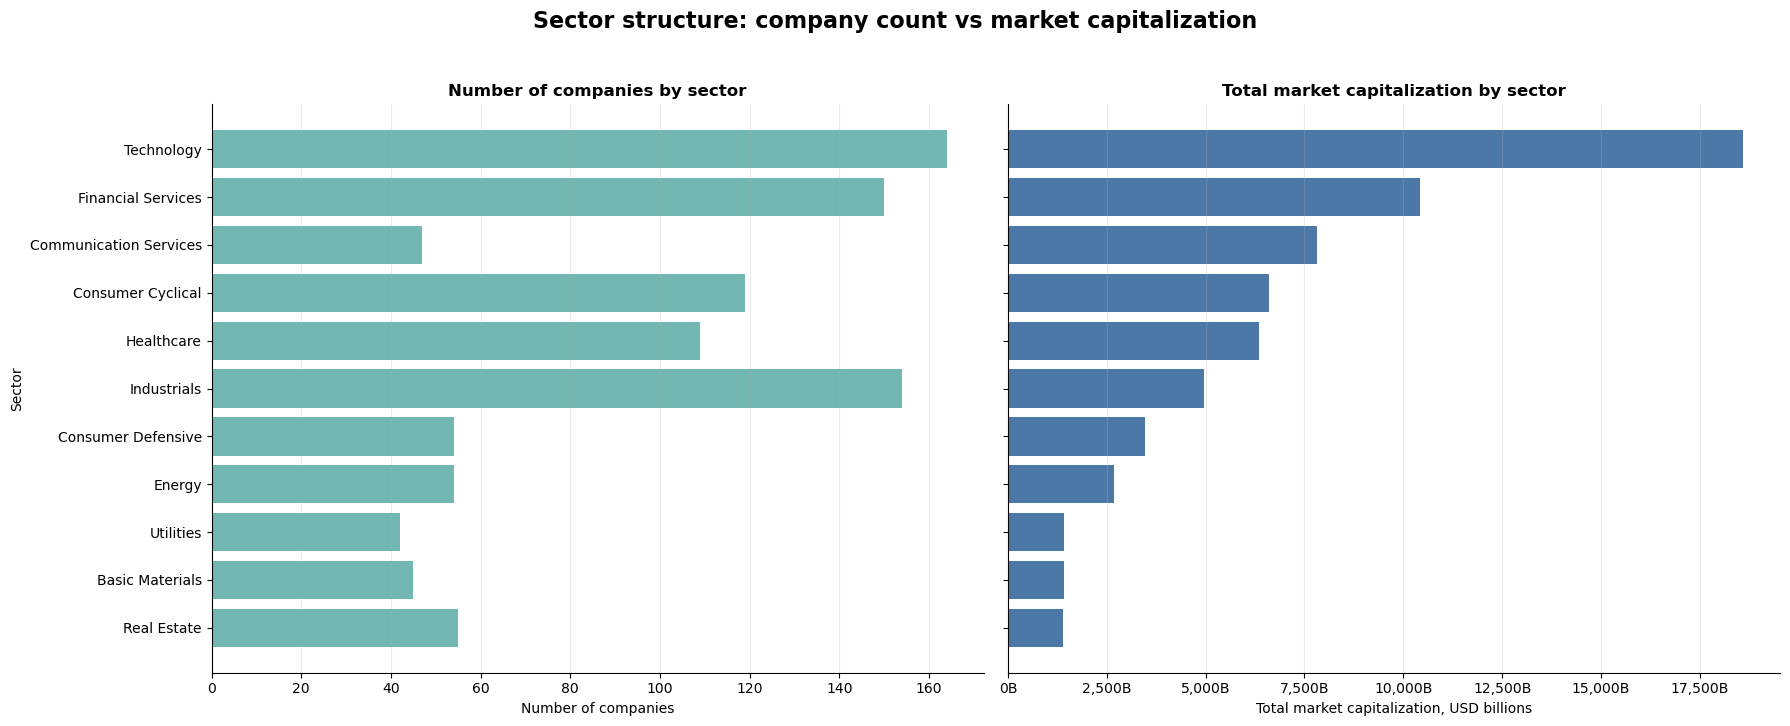

In [13]:
# ============================================================
# 11. Sector overview with aligned sector order
# ============================================================

# Create a clean sector column.
df_sector = df.copy()
df_sector["sector_clean"] = df_sector["sector"].fillna("Unknown")

# Aggregate both metrics in one summary table.
sector_summary = (
    df_sector
    .groupby("sector_clean")
    .agg(
        company_count=("symbol", "count"),
        total_market_cap_b=("market_cap_b", "sum")
    )
    .sort_values("total_market_cap_b", ascending=True)
)

# Create one figure with two columns.
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(18, 7),
    sharey=True
)

ax_count = axes[0]
ax_cap = axes[1]

# Left chart: company count.
ax_count.barh(
    sector_summary.index,
    sector_summary["company_count"],
    color="#72B7B2"
)

ax_count.set_title("Number of companies by sector")
ax_count.set_xlabel("Number of companies")
ax_count.set_ylabel("Sector")
ax_count.grid(axis="x", alpha=0.25)
clean_spines(ax_count)

# Right chart: total market capitalization.
ax_cap.barh(
    sector_summary.index,
    sector_summary["total_market_cap_b"],
    color="#4C78A8"
)

ax_cap.set_title("Total market capitalization by sector")
ax_cap.set_xlabel("Total market capitalization, USD billions")
ax_cap.set_ylabel("")

ax_cap.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax_cap.grid(axis="x", alpha=0.25)
clean_spines(ax_cap)

fig.suptitle(
    "Sector structure: company count vs market capitalization",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

### Teaching point

The two charts may tell different stories.

A sector can be large in terms of company count but small in total value. For investment analysis, economic weight is often more relevant than count.

## BONUS Business Question: Which sectors are above or below the average?

In this section, we compare each sector against a synthetic benchmark called **Sector average**.

The goal is to answer two related business questions:

1. **Which sectors contain more companies than the average sector?**
2. **Which sectors represent more market value than the average sector?**

This distinction is important because the number of companies in a sector does not necessarily tell us how economically important that sector is.

For example, one sector may contain many small companies, while another sector may contain fewer companies but much larger firms.

To make this comparison easier, we create a new artificial row called **Sector average**.

This is **not a real sector**.
It is a benchmark calculated as:

- the average number of companies across sectors;
- the average total market capitalization across sectors.

Then we add this benchmark to the same chart as the real sectors and give it a different color.

This allows us to visually compare each sector against the average and quickly identify sectors that are:

- larger than average in terms of number of companies;
- larger than average in terms of total market capitalization;
- small in company count but large in economic weight;
- large in company count but small in economic weight.

The key lesson is that a chart can be more useful when we add a meaningful reference point.
Here, the **Sector average** works as a visual benchmark that helps turn a simple bar chart into a more analytical comparison.

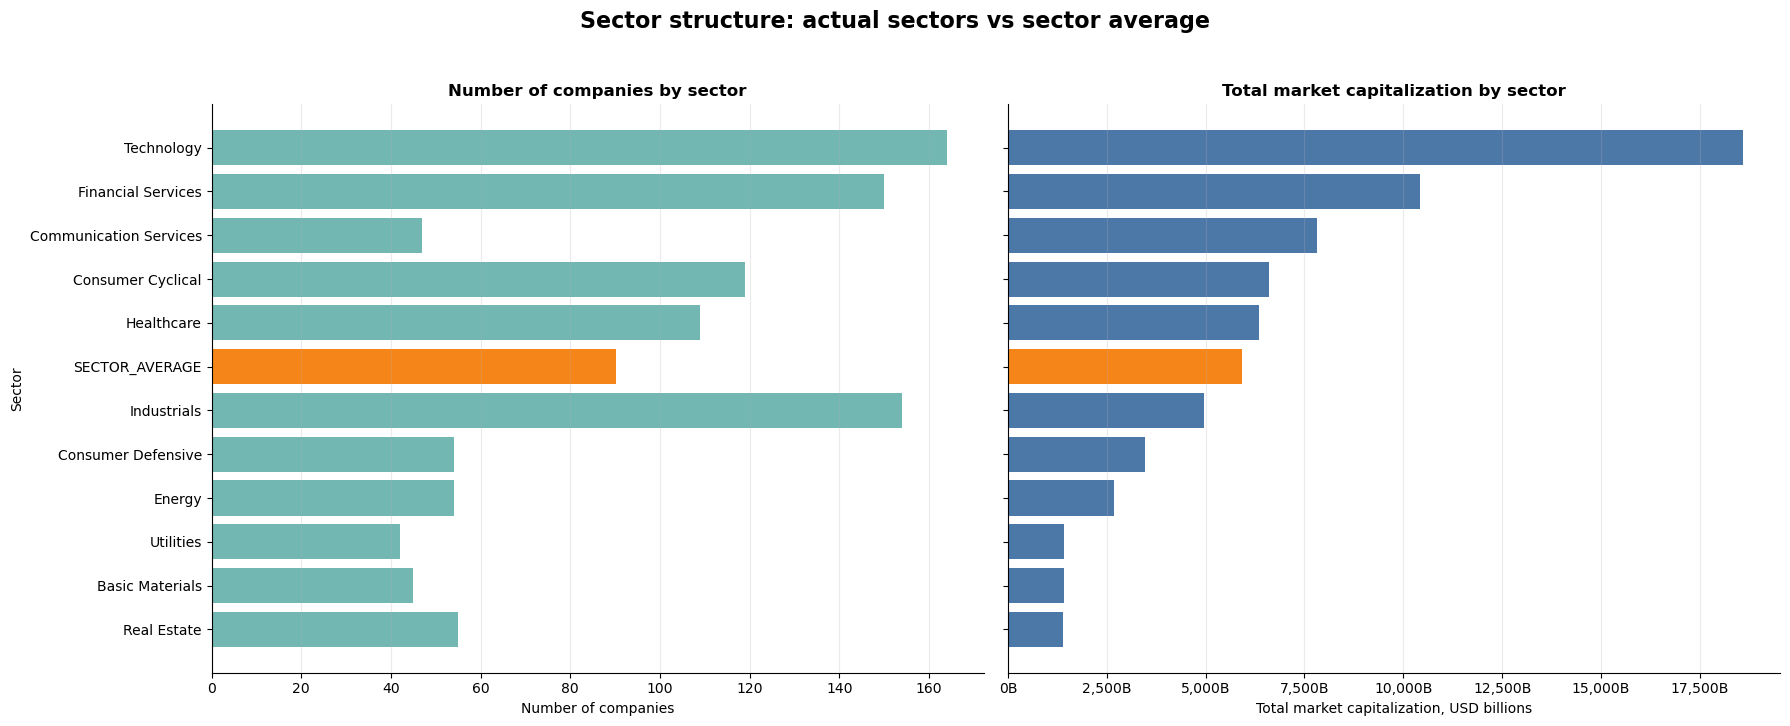

In [14]:
# Calculate the average sector values.
# This creates a synthetic benchmark sector.
#
# Important:
# This is not a real sector.

# It represents the average across all sectors.
sector_average = pd.DataFrame({
    "company_count": [sector_summary["company_count"].mean()],
    "total_market_cap_b": [sector_summary["total_market_cap_b"].mean()]
}, index=["SECTOR_AVERAGE"])

# Add the synthetic average row to the sector summary table.
sector_summary_with_avg = pd.concat(
    [sector_summary, sector_average],
    axis=0
)

# Sort by total market capitalization.
# This keeps the two charts aligned using the same sector order.
sector_summary_with_avg = sector_summary_with_avg.sort_values(
    "total_market_cap_b",
    ascending=True
)

# Assign colors.
# Normal sectors get one color.
# The synthetic average sector gets a different color.
normal_color_count = "#72B7B2"
normal_color_cap = "#4C78A8"
average_color = "#F58518"

colors_count = [
    average_color if sector == "SECTOR_AVERAGE" else normal_color_count
    for sector in sector_summary_with_avg.index
]

colors_cap = [
    average_color if sector == "SECTOR_AVERAGE" else normal_color_cap
    for sector in sector_summary_with_avg.index
]

# Create one figure with two columns.
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(18, 7),
    sharey=True
)

ax_count = axes[0]
ax_cap = axes[1]

# ------------------------------------------------------------
# Left chart: number of companies by sector
# ------------------------------------------------------------
ax_count.barh(
    sector_summary_with_avg.index,
    sector_summary_with_avg["company_count"],
    color=colors_count
)

ax_count.set_title("Number of companies by sector")
ax_count.set_xlabel("Number of companies")
ax_count.set_ylabel("Sector")
ax_count.grid(axis="x", alpha=0.25)
clean_spines(ax_count)

# ------------------------------------------------------------
# Right chart: total market capitalization by sector
# ------------------------------------------------------------

ax_cap.barh(
    sector_summary_with_avg.index,
    sector_summary_with_avg["total_market_cap_b"],
    color=colors_cap
)

ax_cap.set_title("Total market capitalization by sector")
ax_cap.set_xlabel("Total market capitalization, USD billions")
ax_cap.set_ylabel("")
ax_cap.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax_cap.grid(axis="x", alpha=0.25)
clean_spines(ax_cap)

fig.suptitle(
    "Sector structure: actual sectors vs sector average",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

# Business Question 4

## Which companies dominate the market visually?

So far, we have used bar charts to compare companies and sectors.

A bar chart is precise and easy to read, but it can become long when we want to compare many companies at once. A treemap gives us a more compact view of market composition.

In a treemap:

- each rectangle represents one company;
- the area of each rectangle is proportional to market capitalization;
- larger rectangles represent companies with larger market value;
- color can be used to represent sector.

This chart helps answer a simple business question:

> **Are the largest companies similar in size, or does a small group dominate the market?**

For this example, we use the `squarify` library. Matplotlib does not include a native treemap chart, so `squarify` calculates the rectangle layout and Matplotlib renders the final visualization.

The goal is not to replace bar charts. The goal is to show that different charts answer different types of questions:

- use a bar chart when you need accurate ranking and comparison;
- use a treemap when you want to show composition, concentration, and relative size in a compact visual.

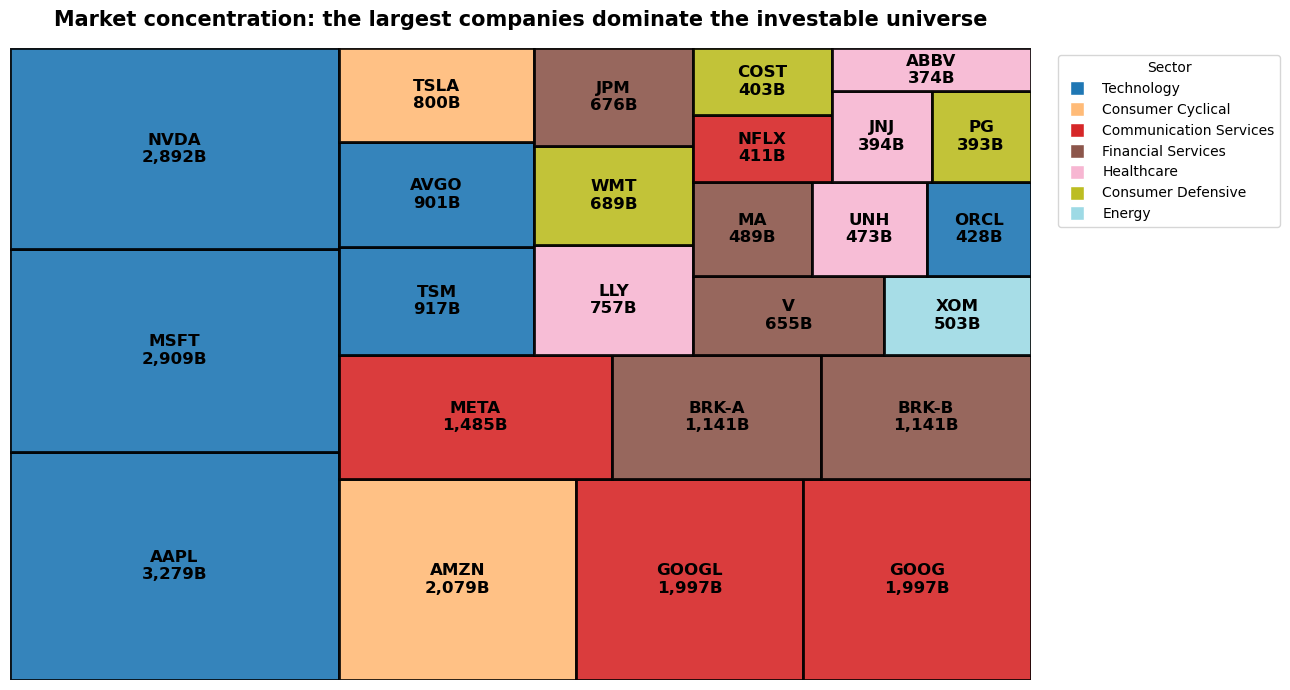

In [15]:
# ============================================================
# 12. Treemap: which companies dominate the market?
# ============================================================

# Business question:
# Are the largest companies similar in size,
# or does a small group dominate the market?
#
# A treemap is useful when we want to show composition.
# Each rectangle represents one company.
# The area of the rectangle is proportional to market capitalization.
#
# In this chart:
# - larger rectangle = larger market capitalization
# - color = sector
# - label = ticker and market capitalization


import squarify

# Select the 25 largest companies by market capitalization.
# We keep only 25 companies because treemaps become hard to read
# when there are too many small rectangles.
top25 = df.nlargest(25, "market_cap_b").copy()

# Sort from largest to smallest.
# This helps squarify place the largest rectangles more prominently.
top25 = top25.sort_values("market_cap_b", ascending=False)

# Replace missing sector values with "Unknown".
# This avoids problems when assigning colors.
top25["sector_clean"] = top25["sector"].fillna("Unknown")

# Create a color map for sectors.
# Each sector receives one color from the tab20 palette.
sectors = top25["sector_clean"].unique()
palette = plt.cm.tab20(np.linspace(0, 1, len(sectors)))
sector_to_color = dict(zip(sectors, palette))

# Assign one color to each company based on its sector.
colors = top25["sector_clean"].map(sector_to_color)

# Create labels for the rectangles.
# Each label shows:
# - the company ticker
# - the market capitalization in USD billions
labels = [
    f"{symbol}\n{market_cap:,.0f}B"
    for symbol, market_cap in zip(top25["symbol"], top25["market_cap_b"])
]

fig, ax = plt.subplots(figsize=(13, 7))

# Draw the treemap.
# sizes controls the area of each rectangle.
# label controls the text displayed inside each rectangle.
# color controls the rectangle colors.
# alpha controls transparency.
squarify.plot(
    sizes=top25["market_cap_b"],
    label=labels,
    color=colors,
    alpha=0.9,
    edgecolor="black",
    linewidth=2,
    text_kwargs={
        "fontsize": 12,
        "color": "black",
        "weight": "bold"
    },
    ax=ax
)

# Add a clear, business-oriented title.
ax.set_title(
    "Market concentration: the largest companies dominate the investable universe",
    fontsize=15,
    fontweight="bold",
    pad=16
)

# Remove axes because a treemap does not need X and Y coordinates.
# The position of each rectangle is not meaningful.
# Only the area is meaningful.
ax.axis("off")

# Create a custom legend for sectors.
# We build it manually because the colors were assigned from a dictionary.
legend_handles = [
    plt.Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        label=sector,
        markerfacecolor=color,
        markersize=10
    )
    for sector, color in sector_to_color.items()
]

# Place the legend outside the chart on the right.
# This keeps the treemap area clean.
ax.legend(
    handles=legend_handles,
    title="Sector",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# Business Question 5

## Are the largest companies also the most profitable?

Size alone is not enough. A company can have massive revenue but low margins, or smaller revenue but very strong profitability.

A scatter plot helps answer:

> **What is the relationship between revenue and net income?**

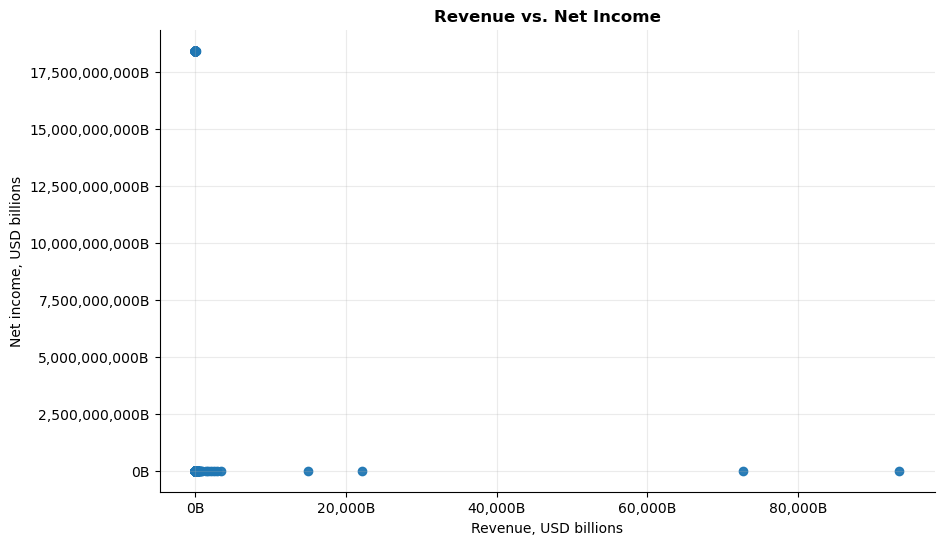

In [16]:
# ============================================================
# 13. Scatter plot, first version
# ============================================================

# A scatter plot is used to study the relationship between two numerical variables.
# x-axis: revenue
# y-axis: net income

plot_df = df.dropna(subset=["revenue_b", "net_income_b"])

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(plot_df["revenue_b"], plot_df["net_income_b"], alpha=0.95)

ax.set_title("Revenue vs. Net Income")
ax.set_xlabel("Revenue, USD billions")
ax.set_ylabel("Net income, USD billions")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.grid(alpha=0.25)
clean_spines(ax)

plt.show()

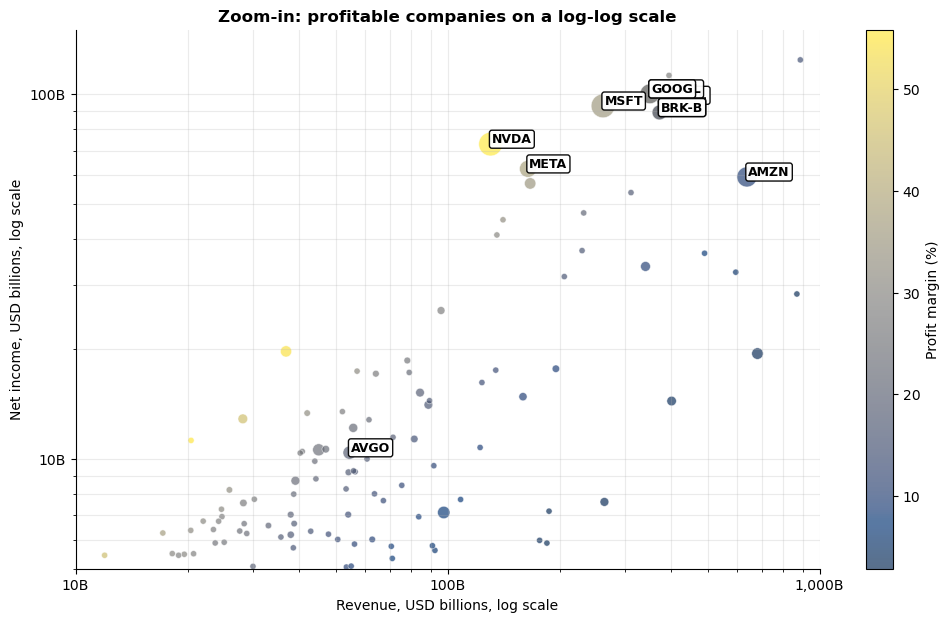

In [17]:
# ============================================================
# 14. Scatter plot, zoom-in with log-log axes
# ============================================================

# In the previous scatter plot, a few extreme values made the chart hard to read.
# Here we zoom in on a more interpretable area:
# - Revenue between 10 and 1,000 USD billions.
# - Net income between 5 and 1500 USD billions.
# - Both axes use logarithmic scales.
# - Marker size represents market capitalization.
# - Marker color represents profit margin.
# - Top companies are annotated with ticker symbols.

scatter_df = df.dropna(
    subset=["revenue_b", "net_income_b", "market_cap_b", "profit_margin_pct"]
).copy()

# Zoom-in area.
# Logarithmic axes require strictly positive values.
scatter_df = scatter_df[
    (scatter_df["revenue_b"] >= 10) &
    (scatter_df["revenue_b"] <= 1000) &
    (scatter_df["net_income_b"] > 5) &
    (scatter_df["net_income_b"] <= 1500)
].copy()

# Keep the largest companies inside the zoom-in area for readability.
scatter_df = scatter_df.nlargest(250, "market_cap_b")

fig, ax = plt.subplots(figsize=(12, 7))

# Convert market capitalization into marker size for the scatter plot.
# The values are divided by 10 to make the bubbles visually manageable.
sizes = scatter_df["market_cap_b"] / 10

# Limit the marker sizes to avoid unreadable extremes:
# - values below 20 are raised to 20, so small companies remain visible;
# - values above 700 are capped at 700, so very large companies do not dominate the chart.

sizes = sizes.clip(lower=20, upper=700)

# Create the scatter plot:
# - X axis: company revenue in USD billions.
# - Y axis: company net income in USD billions.
# - Bubble size: market capitalization, stored in the "sizes" variable.
# - Bubble color: profit margin percentage.
points = ax.scatter(
    scatter_df["revenue_b"],
    scatter_df["net_income_b"],
    s=sizes,
    c=scatter_df["profit_margin_pct"],
    # Use the Viridis color map to represent profit margin values.
    # Lower and higher margins will appear with different colors.
    cmap="cividis", #cmap="cividis"  cmap="plasma"
    # Make bubbles slightly transparent to reduce overlap problems.
    alpha=0.65,
    # Add a white border around each bubble to improve separation.
    edgecolors="white",
    # Set the border thickness around each bubble.
    linewidth=0.5
)

ax.set_xscale("log")
ax.set_yscale("log")

# Annotate the 10 largest companies by market cap inside the zoomed area.
for _, row in scatter_df.nlargest(10, "market_cap_b").iterrows():
    ax.annotate(
        row["symbol"],
        (row["revenue_b"], row["net_income_b"]),
        xytext=(1, 1),
        textcoords="offset points",
        fontsize=9,
        weight="bold",
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="white",
            ec="black",
            alpha=0.95
        )
    )

ax.set_title("Zoom-in: profitable companies on a log-log scale")
ax.set_xlabel("Revenue, USD billions, log scale")
ax.set_ylabel("Net income, USD billions, log scale")

# Axis limits for the zoom-in window.
ax.set_xlim(10, 1000)
ax.set_ylim(5, 150)

ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(billions_formatter))

ax.grid(alpha=0.25, which="both")
clean_spines(ax)

cbar = plt.colorbar(points, ax=ax)
cbar.set_label("Profit margin (%)")

plt.show()

### Teaching point

The improved scatter plot uses several visual encodings:

- x-position: revenue
- y-position: net income
- marker size: market capitalization
- marker color: profit margin
- text annotation: company ticker

# Business Question 6

## Which sectors have better profitability profiles?

A single average can hide large variation. A boxplot is better when we want to compare distributions.

The boxplot answers:

> **Which sectors tend to have higher or lower profit margins, and how dispersed are they?**

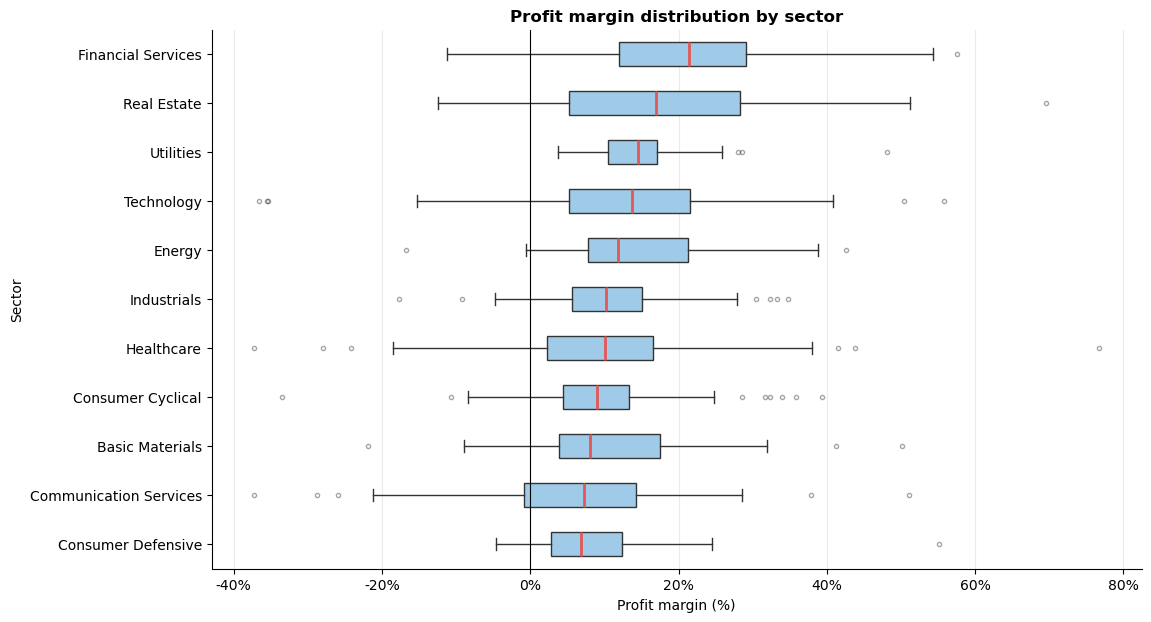

In [18]:
# ============================================================
# 15. Boxplot: profit margin by sector
# ============================================================

# To avoid extreme micro-company effects, keep companies with at least $1B revenue.
# dropna(subset=["sector", "profit_margin_pct"]) is used to remove rows where either
# the sector or the profit margin is missing.
# These fields are required to group companies by sector and compare their
# profitability.
box_df = df[
    (df["revenue_b"] >= 1) &
    (df["profit_margin_pct"].between(-50, 80))
].dropna(subset=["sector", "profit_margin_pct"]).copy()

# Order sectors by median profitability.
sector_order = (
    box_df.groupby("sector")["profit_margin_pct"]
    .median()
    .sort_values(ascending=True)
    .index
)

# Build the input data for the box plot.
# Matplotlib expects a list of numeric arrays, where each array contains
# the profit margin values for one sector.
# box_data = [ [12.5, 18.0, 21.3, 9.7],      # Technology ...]
# The order follows sector_order, so boxes and labels stay aligned.
box_data = [
    box_df.loc[box_df["sector"] == sector, "profit_margin_pct"].values
    for sector in sector_order
]


fig, ax = plt.subplots(figsize=(12, 7))

# Create the horizontal box plot.
# Each box summarizes the distribution of profit margins within one sector.
ax.boxplot(
    # List of arrays: one array of profit margin values per sector.
    box_data,

    # Labels shown next to each box.
    # The order must match the order of box_data.
    # In Matplotlib 3.9+, this parameter is called tick_labels.
    tick_labels=sector_order,

    # Draw boxes horizontally instead of vertically.
    # This makes sector names easier to read.
    vert=False,

    # Allow the boxes to be filled with color.
    # Without this, facecolor would not be applied.
    patch_artist=True,

    # Style of the main box:
    # - facecolor controls the fill color;
    # - edgecolor controls the border color.
    boxprops={"facecolor": "#A0CBE8", "edgecolor": "#333333"},

    # Style of the median line inside each box.
    # Here it is shown in red and made thicker.
    medianprops={"color": "#E45756", "linewidth": 2},

    # Style of the whiskers, which extend from the box to non-outlier values.
    whiskerprops={"color": "#333333"},

    # Style of the caps at the end of each whisker.
    capprops={"color": "#333333"},

    # Style of the outlier points:
    # - marker="o" uses circular markers;
    # - markersize=3 keeps them small;
    # - alpha=0.35 makes them semi-transparent.
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.35}
)

ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Profit margin distribution by sector")
ax.set_xlabel("Profit margin (%)")
ax.set_ylabel("Sector")
ax.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax.grid(axis="x", alpha=0.25)
clean_spines(ax)

plt.show()

### Interpretation

The median line inside each box shows the typical company in that sector. The box shows the middle 50% of observations. Outliers show unusual companies.

This chart is useful because it prevents us from overreacting to one famous company or one extreme value.

# Business Question 7

## Which companies combine growth, profitability and risk?

Investors often want companies that grow, generate profits, and do not carry excessive market risk.

A bubble scatter plot can answer:

> **Which companies are growing while maintaining strong margins, and how risky are they?**

Here:

- x-axis = revenue growth
- y-axis = profit margin
- color = beta
- bubble size = market capitalization

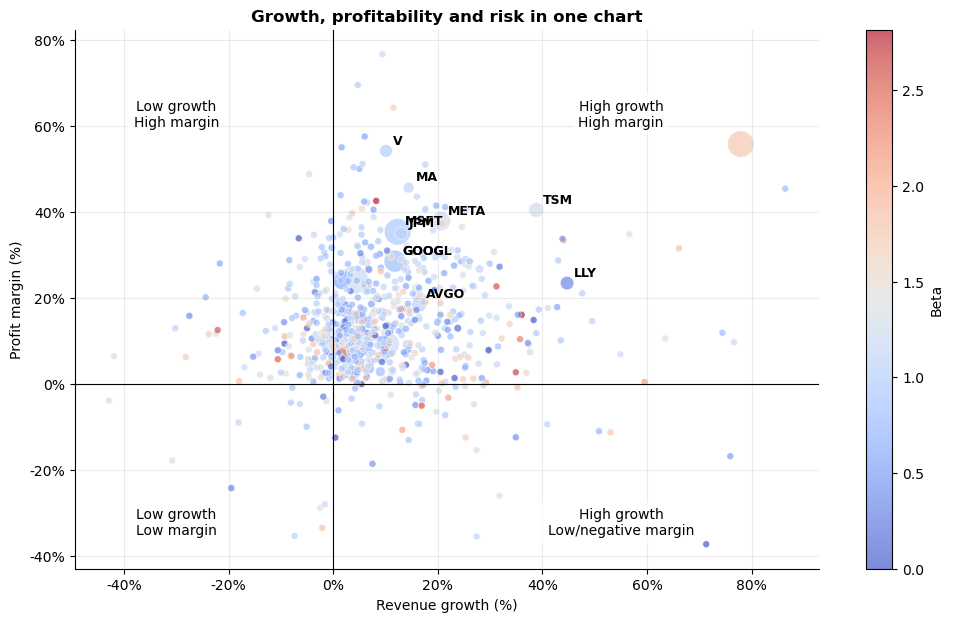

In [19]:
# ============================================================
# 16. Growth vs profitability vs risk
# ============================================================

# Filter extreme values to make the chart readable.
# This does not mean those values are unimportant; it means they would dominate the visual scale.
growth_df = df[
    (df["market_cap_b"] >= 10) &
    (df["revenue_growth_pct"].between(-50, 100)) &
    (df["profit_margin_pct"].between(-50, 80)) &
    (df["beta"].between(0, 3))
].dropna(subset=["revenue_growth_pct", "profit_margin_pct", "beta", "market_cap_b"]).copy()

fig, ax = plt.subplots(figsize=(12, 7))

sizes = (growth_df["market_cap_b"] / 8).clip(lower=25, upper=600)

points = ax.scatter(
    growth_df["revenue_growth_pct"],
    growth_df["profit_margin_pct"],
    s=sizes,
    c=growth_df["beta"],
    cmap="coolwarm",
    alpha=0.65,
    edgecolors="white",
    linewidth=0.5
)

# Reference lines create four quadrants.
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)

# Add quadrant labels.
ax.text(55, 60, "High growth\nHigh margin", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
ax.text(55, -35, "High growth\nLow/negative margin", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
ax.text(-30, 60, "Low growth\nHigh margin", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
ax.text(-30, -35, "Low growth\nLow margin", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))

# Annotate a few attractive candidates: positive growth, positive margin, beta below 1.5.
candidates_for_labels = growth_df[
    (growth_df["revenue_growth_pct"] > 10) &
    (growth_df["profit_margin_pct"] > 15) &
    (growth_df["beta"] < 1.5)
].nlargest(10, "market_cap_b")

for _, row in candidates_for_labels.iterrows():
    ax.annotate(
        row["symbol"],
        (row["revenue_growth_pct"], row["profit_margin_pct"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        weight="bold"
    )

ax.set_title("Growth, profitability and risk in one chart")
ax.set_xlabel("Revenue growth (%)")
ax.set_ylabel("Profit margin (%)")
ax.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax.grid(alpha=0.25)
clean_spines(ax)

cbar = plt.colorbar(points, ax=ax)
cbar.set_label("Beta")

plt.show()

# Business Question 8

## Can we build a transparent investment score?

A professional analyst would use a much richer model. For this class, we build a simple educational scoring model.

The goal is not to declare the best stocks. The goal is to show how a report can move from raw data to a decision framework.

The score combines:

- size: market capitalization
- profitability: profit margin
- growth: revenue growth
- efficiency: return on equity
- cash generation: free cash flow
- risk: beta, where lower is better
- valuation: forward P/E, where lower is better

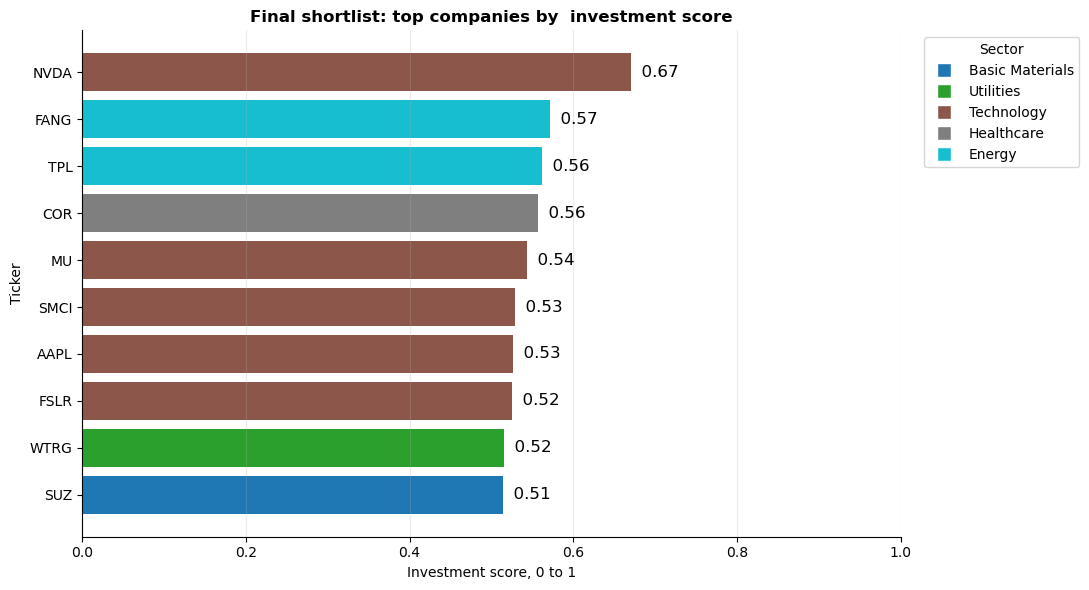

In [20]:
# ============================================================
# 17. Build an investment score
# ============================================================

score_columns = [
    "market_cap_b",
    "profit_margin_pct",
    "revenue_growth_pct",
    "return_on_equity_pct",
    "free_cashflow_b",
    "beta",
    "pe_forward"
]

# Keep only rows where all scoring fields are present.
# A score is only meaningful when all components are available.
score_df = df.dropna(subset=score_columns + ["symbol", "company_name", "sector"]).copy()

# Remove extreme values that would distort min-max scaling.
# These thresholds are teaching choices, not universal rules:
# every threshold should be documented and challenged in a real workflow.
score_df = score_df[
    (score_df["market_cap_b"] >= 10) &               # exclude micro-caps
    (score_df["profit_margin_pct"].between(-20, 80)) &
    (score_df["revenue_growth_pct"].between(-50, 100)) &
    (score_df["return_on_equity_pct"].between(-100, 200)) &
    (score_df["free_cashflow_b"] > 0) &              # positive free cash flow only
    (score_df["beta"].between(0, 3)) &
    (score_df["pe_forward"].between(1, 80))
].copy()

if score_df.empty:
    raise ValueError(
        "The scoring dataset is empty after filtering. "
        "Relax the thresholds or inspect missing values in the required columns."
    )

def minmax(series):
    # Min-max scaling maps every value into the [0, 1] range.
    # If all values are identical, return 0.5 to avoid division by zero.
    lo, hi = series.min(), series.max()
    return pd.Series(0.5, index=series.index) if lo == hi else (series - lo) / (hi - lo)

# Positive factors: a higher raw value should produce a higher score.
score_df["size_score"]      = minmax(score_df["market_cap_b"])
score_df["margin_score"]    = minmax(score_df["profit_margin_pct"])
score_df["growth_score"]    = minmax(score_df["revenue_growth_pct"])
score_df["roe_score"]       = minmax(score_df["return_on_equity_pct"])
score_df["fcf_score"]       = minmax(score_df["free_cashflow_b"])

# Negative factors: a lower raw value is preferable, so we invert the scaled result.
# A company with the lowest beta gets risk_score = 1; the highest beta gets 0.
score_df["risk_score"]      = 1 - minmax(score_df["beta"])
score_df["valuation_score"] = 1 - minmax(score_df["pe_forward"])

# Weighted sum of all component scores.
# Weights are subjective: in a real investment committee they should be
# debated and tested with sensitivity analysis.
score_df["investment_score"] = (
    0.15  * score_df["size_score"]      +
    0.20  * score_df["margin_score"]    +
    0.20  * score_df["growth_score"]    +
    0.15  * score_df["roe_score"]       +
    0.15  * score_df["fcf_score"]       +
    0.075 * score_df["risk_score"]      +
    0.075 * score_df["valuation_score"]
)

# Keep the top 10 companies by investment score.
shortlist = score_df.sort_values("investment_score", ascending=False).head(10).copy()

# ── Chart ────────────────────────────────────────────────────────────────────

# Sort ascending so that the highest score appears at the top of the chart
# (matplotlib draws horizontal bars from bottom to top).
plot_shortlist = shortlist.sort_values("investment_score", ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))

# Assign one color per sector.
sectors = plot_shortlist["sector"].fillna("Unknown").unique()
palette = plt.cm.tab10(np.linspace(0, 1, len(sectors)))   # evenly spaced colors from tab10
sector_to_color = dict(zip(sectors, palette))              # map sector name → color
bar_colors = plot_shortlist["sector"].fillna("Unknown").map(sector_to_color)

ax.barh(plot_shortlist["symbol"], plot_shortlist["investment_score"], color=bar_colors)

ax.set_title("Final shortlist: top companies by  investment score")
ax.set_xlabel("Investment score, 0 to 1")
ax.set_ylabel("Ticker")
# Leave 15 % of extra space on the right so bar labels don't get clipped.
ax.set_xlim(0, max(1, plot_shortlist["investment_score"].max() * 1.15))
ax.grid(axis="x", alpha=0.25)
clean_spines(ax)

annotate_hbar(ax, fmt="{:.2f}")

# Build a custom legend manually because the bars were colored individually,
# not through a grouped plot that would generate a legend automatically.
legend_handles = [
    plt.Line2D([0], [0], marker="s", color="w", label=sector,
               markerfacecolor=color, markersize=10)
    for sector, color in sector_to_color.items()
]
ax.legend(handles=legend_handles, title="Sector", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

# Business Question 9

## How did the shortlisted stocks perform over the last month?

A static score tells us where a company stands today. Price performance tells us how the market has been pricing it recently.

We compare the shortlisted stocks over the last 30 trading days against the S&P 500 as a benchmark.

Each series is normalized to 1 on the first available trading day, so all lines start from the same point and percentage moves are directly comparable.

Stocks that outperformed the benchmark are highlighted in blue; those that lagged are shown in grey.

[*********************100%***********************]  11 of 11 completed


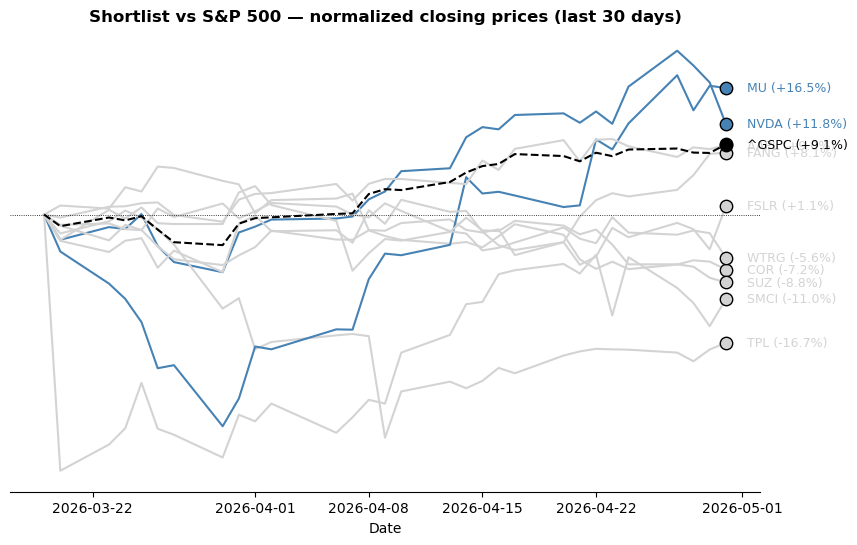

In [ ]:
# ============================================================
# 18. Normalized price comparison: shortlist vs S&P 500
# ============================================================

import yfinance as yf

# Build the ticker list from the shortlist, then append the benchmark.
tickers = shortlist["symbol"].tolist() + ["^GSPC"]

# Download daily closing prices for the last 30 days.
data = yf.download(tickers, period="30d", interval="1d", auto_adjust=True)
closing_prices = data["Close"]

# Normalize each series to 1 on the first available trading day.
# Dividing every value by the first row means day-0 = 1 for all tickers,
# so lines start at the same point and percentage moves are directly comparable.
normalized_prices = closing_prices / closing_prices.iloc[0]

# ── Chart ────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 6))

sp500_final = normalized_prices["^GSPC"].iloc[-1]

for ticker in tickers:
    ticker_final = normalized_prices[ticker].iloc[-1]

    # S&P 500 is the benchmark: black dashed line.
    # Stocks that beat it are highlighted in steelblue; laggards in lightgrey.
    if ticker == "^GSPC":
        line_color, line_style = "black", "--"
    else:
        line_color = "steelblue" if ticker_final > sp500_final else "lightgrey"
        line_style = "-"

    ax.plot(normalized_prices.index, normalized_prices[ticker],
            color=line_color, linestyle=line_style, linewidth=1.5)

    # Mark the last data point with a circle so the annotation has a visual anchor.
    final_date  = normalized_prices.index[-1]
    ax.scatter(final_date, ticker_final,
               color=line_color, edgecolor="black", zorder=5, s=80)

    # Compute percentage change since day 0.
    # Because the series is normalized to 1, (final - 1) * 100 gives the % gain/loss.
    pct_change    = (ticker_final - 1) * 100
    label_text    = f"{ticker} ({pct_change:+.1f}%)"

    # Place the label 15 points to the right of the final marker.
    ax.annotate(label_text,
                xy=(final_date, ticker_final),
                xytext=(15, 0),
                textcoords="offset points",
                va="center",
                fontsize=9,
                color=line_color)

# Clean up the frame: keep only the x-axis spine.
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.yaxis.set_ticks([])

# Draw a horizontal reference line at 1 (= no change from day 0).
ax.axhline(1, color="black", linewidth=0.6, linestyle=":")

ax.set_title("Shortlist vs S&P 500 — normalized closing prices (last 30 days)")
ax.set_xlabel("Date")

# Extra right margin so ticker labels are not clipped by the figure edge.
fig.subplots_adjust(right=0.75)

plt.show()